<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/linear_regression_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Семинар. Линейная регрессия</b></h1>

В этом ноутбуке мы реализуем алгоритм линейной регрессии и протестируем его на искусственных данных. Для удобства данные методы будем реализовывать в виде классов в Python наподобие соотвествующих классов из sklearn.

In [ ]:
import numpy as np
import pandas as pd
import scipy.linalg as sla
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# 1. Линейная регрессия

Линейные методы предполагают, что между признаками объекта (features) и целевой переменной (target/label) существует линейная зависимость, то есть
$$y = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b, $$
где
* $y$ --- целевая переменная (то, что мы хотим предсказать),
* $x_1, \ldots, x_n$ --- признаки объекта $\mathbf{x}$,
* $w_i$ --- вес $i$-го признака, $b$ --- bias (смещение, свободный член).

Часто предполагают, что объект $\mathbf{x}$ содержит в себе фиктивный признак равный 1 для представления свободного члена $b$. В этом случае формула принимает простой вид:
$$y = \langle \mathbf{w}, \mathbf{x} \rangle,$$
где $\langle \cdot, \cdot \rangle$ -- скалярное произведение векторов $\mathbf{w}$, $\mathbf{x} \in \mathbb{R}^n$.

В многомерном случае формулу линейной регрессии можно переписать следующим образом:
$$ \mathbf{y} = X\mathbf{w}, $$
где
* $\mathbf{y}$ -- столбец размера $\ell$ (количество объектов),
* $X$ --- матрица признаков размера $\ell \times n$ (каждая строка матрицы является вектором признаков объекта),
* $\mathbf{w}$ -- вектор весов размера $n$.

**Лосс:**
$$
\begin{aligned}
L(\mathbf{w}) &= \frac{1}{\ell}||\mathbf{y}_{pred} - \mathbf{y}||^2_2 =\\
&= \frac{1}{\ell}||X\mathbf{w} - \mathbf{y}||^2_2 = \frac{1}{\ell}\sum_{i=1}^{\ell}\left(\sum_{j=1}^{n} x_{ij}w_j - y_i\right)^2
\end{aligned}
$$

### 1.1 Аналитическое решение

Минимизация ошибки по методу наименьших квадратов дает решение: $$ \mathbf{w} = (X^TX)^{-1}X^T \mathbf{y} $$

Реализуем класс линейной регрессии с помощью этой формулы.

In [ ]:
class MyLinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        # Принимает на вход X, y и вычисляет веса по данной выборке
        # Не забудьте про фиктивный признак равный 1
        X = np.array(X)
        y = np.array(y)
        assert len(y.shape) == 1 and len(X.shape) == 2
        '''
        assert — это встроенная в Python инструкция для проверки условий.
        Если условие истинно, программа продолжает выполнение; если ложно — выбрасывается исключение AssertionError с сообщением (если оно указано).
        В коде ниже assert используется для проверки корректности входных данных. Это помогает быстро обнаружить ошибки в формате
        переданных данных и избежать неожиданного поведения (например, когда вместо двумерного массива подали одномерный).
        '''
  #Чтобы определить размер каждого измерения (или оси) в массиве NumPy, воспользуйтесь атрибутом .shape.
  #Этот атрибут возвращает кортеж, отображающий размерности массива: Для массива [[1,23,4],[2,4,5]] он вернет (2,3)
        assert X.shape[0] == y.shape[0]
#Тут важно различать размерность массива (количество осей) и размеры по осям.
#len(X.shape) – это количество осей (ранг массива).
#Если X – обычная таблица (матрица) размера ℓ × m, то X.shape будет (ℓ, m), а len(X.shape) == 2. Значит, это двумерный массив.
#X.shape[0] – это количество строк (объектов) в массиве X.
#X.shape[1] – количество столбцов (признаков).
        y = y[:, np.newaxis] # ell, 1, те l одномерных массивов
        l, n = X.shape

        X_train = np.hstack((X, np.ones((l, 1)))) #С помощью функции hstack() вы можете присоединять данные по горизонтальной оси.

        self.w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y #inv - вычисление обратной матрицы. @-матричное умножение

        return self

    def predict(self, X):
        # Принимает на вход X и возвращает ответы модели
        # Не забудьте про фиктивный признак равный 1
        l, n = X.shape

        X_train = np.hstack((X, np.ones((l, 1)))) #добавляем к X еще столбец единиц, чтобы можно было использовать скалярное произведение x*w

        y_pred = X_train @ self.w

        return y_pred

    def get_weights(self):
        return self.w.copy()
        # copy тут используется неспроста. Если copy не использовать, то get_weights()
        # выдаст ссылку на объект, а, значит, модифицируя результат применения функции
        # get_weights() где-то в коде, вы модифицируете и веса self.w. Таким образом, мы будем перенахзначать веса модели и будет ерунда.
        # Если вы хотите модифицировать веса, (например, в fit), используйте self.w


#### Тестирование
Сначала сгенерируем искусственные данные для теста моделей

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
def linear_expression(x):
    return 5 * x + 6

In [ ]:
# по признакам сгенерируем значения таргетов с некоторым шумом
objects_num = 50
X = np.linspace(-5, 5, objects_num) #создаёт 50 чисел, равномерно распределённых между -5 и 5 (оба конца включены). Шаг между соседними числами будет постоянным
y = linear_expression(X) + np.random.randn(objects_num) * 5 #np.random.randn(objects_num) * 5 — генерирует 50 случайных чисел из нормального
#распределения (среднее 0, дисперсия 1), затем умножаем на 5, чтобы увеличить разброс (стандартное отклонение становится 5). Это шум.

# выделим половину объектов на тест
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5)

Нанесем точки выборки и зависимость на график для наглядности

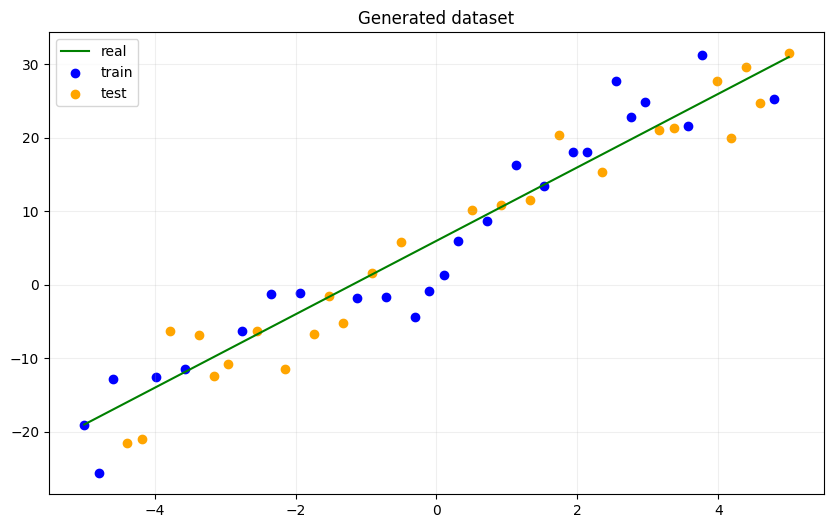

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X, linear_expression(X), label='real', c='g')
plt.scatter(X_train, y_train, label='train', c='b')
plt.scatter(X_test, y_test, label='test', c='orange')

plt.title("Generated dataset")
plt.grid(alpha=0.2) #альфа отвечает за толщину стенок
plt.legend()
plt.show()

Обучим модель на трейне и предскажем результаты на тесте

In [ ]:
regressor = MyLinearRegression()

regressor.fit(X_train[:, np.newaxis], y_train)

predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weights()
w

array([[5.23683606],
       [6.092962  ]])

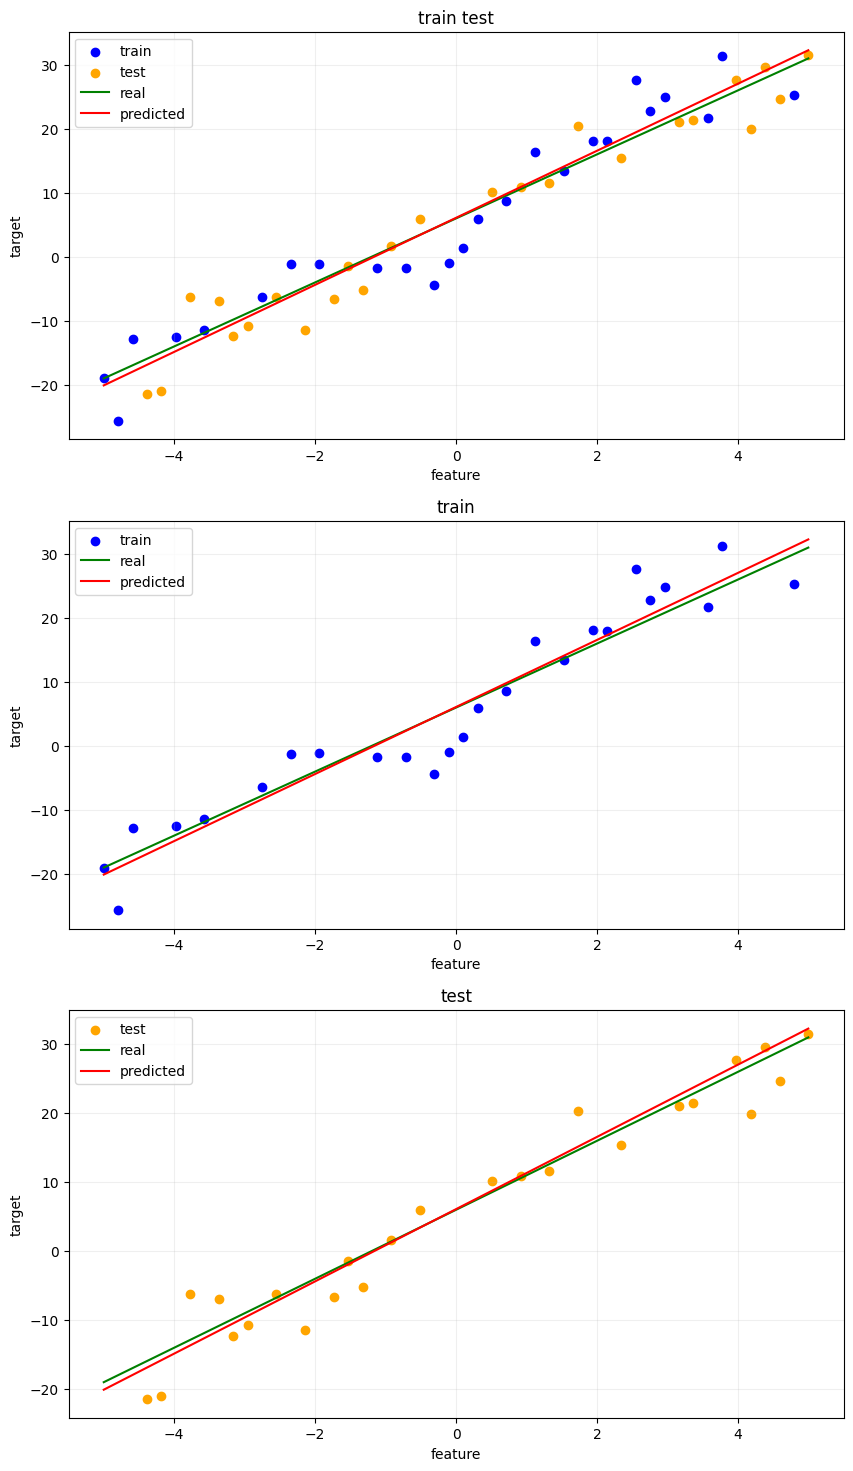

In [ ]:
plt.figure(figsize=(10,18))
ax = None

for i, types in enumerate([['train','test'], ['train'], ['test']]):
#Вы не можете передать ['train','test'],'test','train' в enumerate, потому что это не один итерируемый объект,
#а три отдельных аргумента. enumerate принимает один итерируемый объект (список, кортеж и т.д.) и опционально начальный индекс.
#Поэтому нам нужен список (или кортеж) из трёх элементов, каждый из которых сам является списком (или кортежем) строк.
  ax = plt.subplot(3,1,i+1)
  if 'train' in types:
      plt.scatter(X_train, y_train, label='train', c='b')
  if 'test' in types:
      plt.scatter(X_test, y_test, label='test', c='orange')

  plt.plot(X, linear_expression(X), label='real', c='g')
  plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

  plt.ylabel('target')
  plt.xlabel('feature')
  plt.title(" ".join(types))
  plt.grid(alpha=0.2)
  plt.legend()
plt.show()

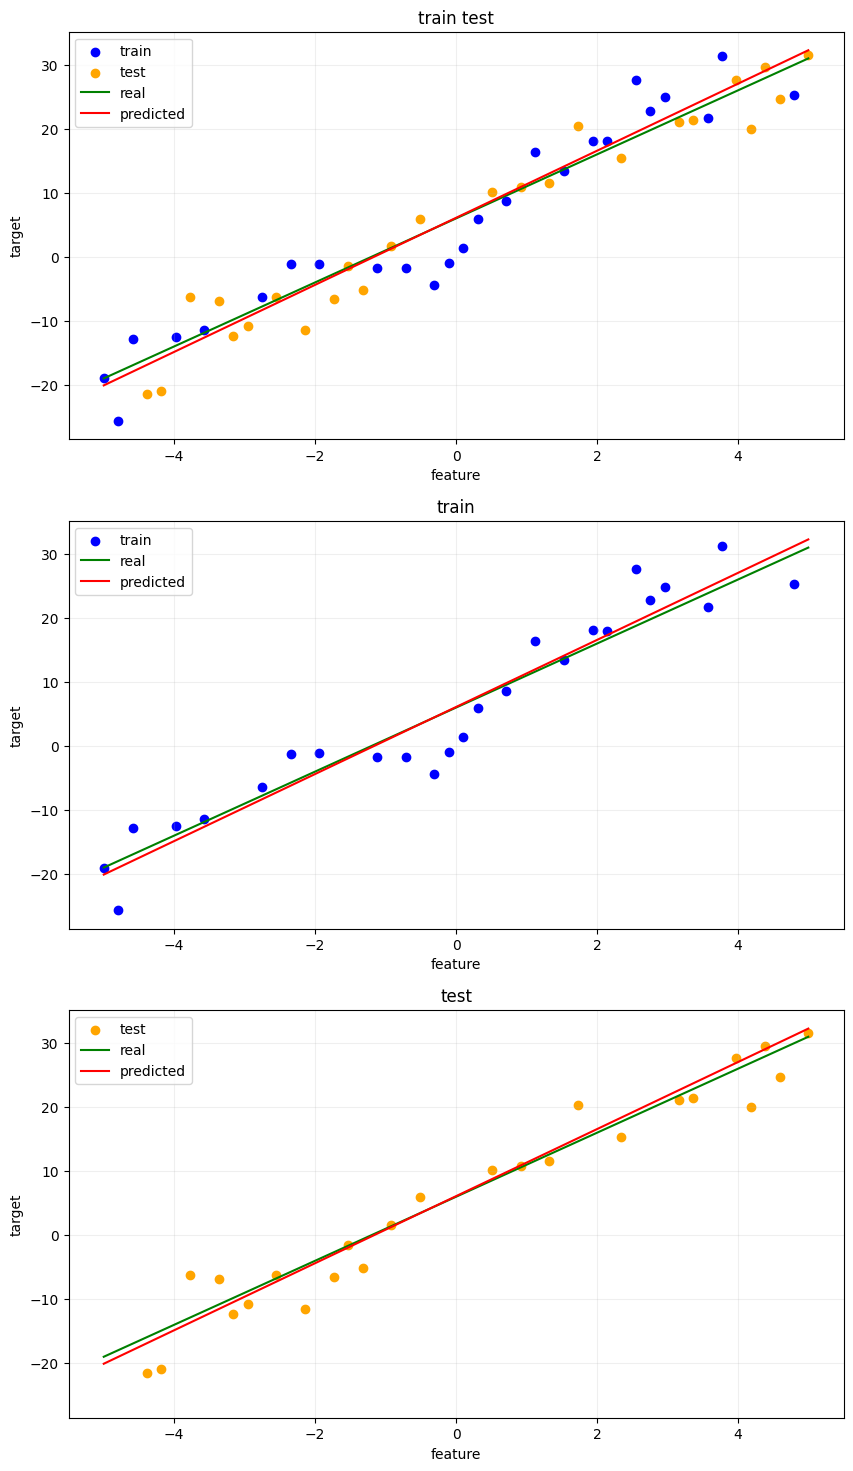

In [ ]:
plt.figure(figsize=(10, 18))

ax = None #переменная для хранения текущей оси; позже она используется, чтобы все подграфики имели одинаковый масштаб по оси Y

#Порядок индексов в enumerate задаётся автоматически в соответствии с порядком следования элементов в итерируемом объекте.
#Начальный индекс по умолчанию — 0. Для каждого следующего элемента индекс увеличивается на 1
#Первый элемент списка — ['train', 'test']. enumerate присваивает i = 0, types = ['train', 'test'].
#Второй элемент — ['train']. i = 1, types = ['train'].
#Третий элемент — ['test']. i = 2, types = ['test'].
for i, types in enumerate([['train', 'test'], ['train'], ['test']]):
    ax = plt.subplot(3, 1, i + 1, sharey=ax) #Создаёт 3 графика в 3 строки и 1 столбец. Номер текущего подграфика i+1. sharey=ax заставляет все подграфики использовать одну и ту же вертикальную шкалу.
 #В каждой итерации цикла создаётся один подграфик (его номер определяется как i+1). При i=0 создаётся первый подграфик, при i=1 — второй, при
 #i=2 — третий. В итоге после цикла у нас будет три подграфика, расположенных вертикально. Это эквивалентно созданию всех трёх сразу, но делается последовательно для удобства.
#Вы убрали sharey=ax, и графики выглядят так же, потому что диапазоны значений по оси Y на всех трёх подграфиках одинаковы
 #(все они отображают одни и те же данные). Если бы на одном из графиков были сильно отличающиеся значения, sharey=ax заставил
 #бы все подграфики подстроить шкалу под самый широкий диапазон. В вашем случае этого не потребовалось, поэтому видимых изменений нет.
    if 'train' in types:
        plt.scatter(X_train, y_train, label='train', c='b')
    if 'test' in types:
        plt.scatter(X_test, y_test, label='test', c='orange')

    plt.plot(X, linear_expression(X), label='real', c='g')
    plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

    plt.ylabel('target')
    plt.xlabel('feature')
    plt.title(" ".join(types))
    plt.grid(alpha=0.2)
    plt.legend()

plt.show()

Сравним с реализацией из sklearn

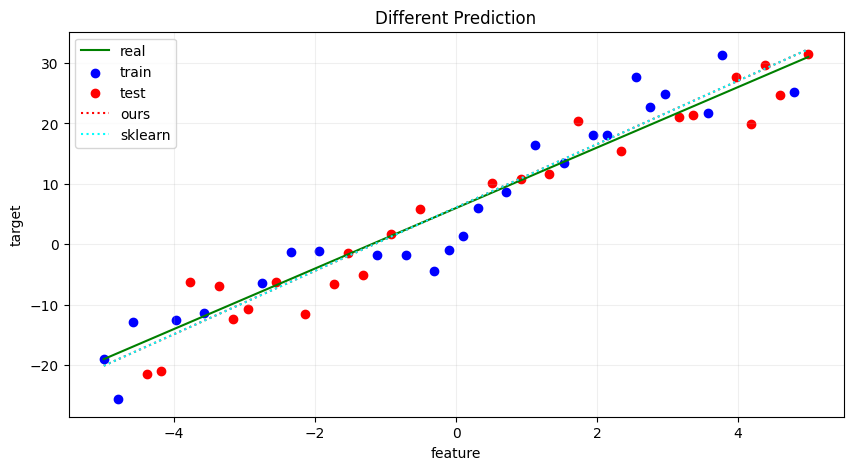

In [ ]:
sk_reg = LinearRegression().fit(X_train[:, np.newaxis], y_train)

plt.figure(figsize=(10, 5))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train', c='b')
plt.scatter(X_test, y_test, label='test', c='r')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='ours', c='r', linestyle=':')
plt.plot(X, sk_reg.predict(X[:, np.newaxis]), label='sklearn', c='cyan', linestyle=':')

plt.title("Different Prediction")
plt.ylabel('target')
plt.xlabel('feature')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [ ]:
sk_reg.coef_, sk_reg.intercept_

#coef_ — массив коэффициентов при признаках (в данном случае один элемент, так как признак один).
#intercept_ — значение свободного члена (bias).


(array([5.23683606]), np.float64(6.092961996567073))

#### Результаты

In [ ]:
from sklearn.metrics import mean_squared_error

train_predictions = regressor.predict(X_train[:, np.newaxis])
test_predictions = regressor.predict(X_test[:, np.newaxis])

print('Train MSE: ', mean_squared_error(y_train, train_predictions))
print('Test MSE: ', mean_squared_error(y_test, test_predictions))

Train MSE:  18.873188130949906
Test MSE:  14.090044578309039


### 1.2. Градиентная оптимизация

Для линейной регрессии решение задачи оптимизации можно выписать в явном виде.Но такое случается не для всех задач (это мы еще увидим позже). По этим причинам, мы воспользуемся методом градиентного спуска для оптимизации эмпирического риска.

Градиентый спуск заключается в следующих шагах:
1. Расчёт $\displaystyle\frac{\partial{L}}{\partial{\mathbf{w}}}$ -- градиента функции потерь $L(\mathbf{w})$ -- от значения параметров модели (весов $\mathbf{w}$);
2. Шаг спуска -- изменение весов $\mathbf{w}$ в сторону антиградиента с некоторым коэффициентом $\alpha$ (он же learning rate):
$$\mathbf{w} := \mathbf{w} - \alpha\frac{\partial{L}}{\partial{\mathbf{w}}};$$
3. Повторение п.1 и п.2 пока не наблюдается сходимость (изменения ошибки малы или отсутсвуют).



**Цель:** Реализуем новые классы линейной регрессии, в которой оптимизация проводится методами градиентного спуска.

**Предполагаемая зависимость:** $\mathbf{y} = X\mathbf{w}$, где $\mathbf{y} \in \mathbb{R}^{\ell\times 1}, X \in \mathbb{R}^{\ell\times n}, \mathbf{w} \in \mathbb{R}^{n\times 1}$


**Минимизируемая функция:**
$$
L(\mathbf{w}) = \frac{1}{\ell} ||\mathbf{y}_{pred} - \mathbf{y}||^2 = \frac{1}{\ell}||X\mathbf{w} - \mathbf{y}||^2 = \frac{1}{\ell}(X\mathbf{w} - \mathbf{y})^T(X\mathbf{w} - \mathbf{y}) = \frac{1}{\ell}(\mathbf{w}^TX^TX\mathbf{w} - 2\mathbf{y}^TX\mathbf{w} + \mathbf{y}^T\mathbf{y})
$$

**Градиент относительно $\mathbf{w}$:**
$$
\frac{\partial{L}}{\partial{\mathbf{w}}} = \frac{2}{\ell}(X^TX\mathbf{w} - X^T\mathbf{y}) = \frac{2}{\ell}X^T(\mathbf{y}_{pred} - \mathbf{y}) \,\, \in \mathbb{R}^{n \times 1}
$$

In [ ]:
class MyGradientLinearRegression(MyLinearRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs) # передает именные параметры родительскому конструктору

    def fit(self, X, y, lr=0.01, max_iter=100):
        # Принимает на вход X, y и вычисляет веса по данной выборке
        # Не забудьте про фиктивный признак равный 1
        X = np.array(X)
        y = np.array(y)
        assert len(y.shape) == 1 and len(X.shape) == 2
        assert X.shape[0] == y.shape[0] #проверка, что совпадает кол-во наблюдений

        y = y[:, np.newaxis] #перевод в вектор столбец
        l, n = X.shape # l - кол-во наблюдений, n - кол-во параметров

        # Добавляем признак из единиц
        X_train = np.hstack((X, np.ones((l, 1))))  # [l, n+1] добавляем столбец 1

        self.w = np.random.randn(n + 1, 1) #назначаем случ веса, чтоб к ним град спуск применить

        self.losses = []

        for iter_num in range(max_iter):
            y_pred = self.predict(X)
            self.losses.append(mean_squared_error(y, y_pred))

            grad = self._calc_gradient(X_train, y, y_pred)

            assert grad.shape == self.w.shape, \
            f"gradient shape {grad.shape} is not equal weight shape {self.w.shape}" #проверяем, что размерности наших весов и градиента совпадают, чтобы делать вычитание

            self.w -= lr * grad #град спуск с learning rate(чтобы были мелкие шаги)

        return self

    def _calc_gradient(self, X, y, y_pred):
        grad = (2. / X.shape[0]) * (X.T @ (y_pred - y))  #x.shape[0] - кол-во наблюдений

        return grad

    def get_losses(self):
        return self.losses

#### Тестирование

Посчитаем предсказания на сгенерированном датасете

In [ ]:
regressor = MyGradientLinearRegression()

l = regressor.fit(X_train[:, np.newaxis], y_train, max_iter=100).get_losses()
#Всё верно. `fit` обучает модель, обновляя `self.w`, а затем возвращает сам объект (`return self`). Поэтому можно сразу вызвать `get_losses()`
#для получения списка потерь. После этого `regressor` уже содержит обученные веса, и предсказания делаются с их использованием.
predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weights()

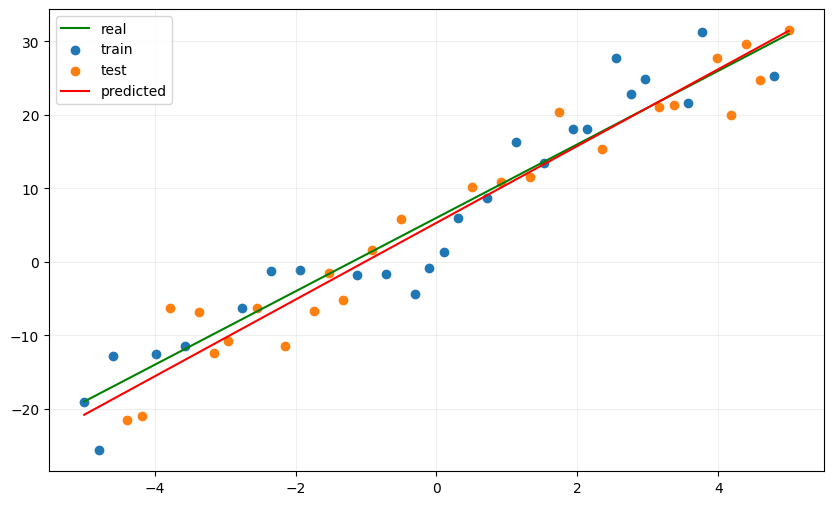

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

plt.grid(alpha=0.2)
plt.legend()
plt.show()

Построим таккже график лосса во время обучения

In [ ]:
l

[207.26295923696875,
 159.88702243072558,
 126.24045428346086,
 102.25981777241154,
 85.08774903197379,
 72.71484543031775,
 63.727891007317446,
 57.13284336188578,
 52.230382264949256,
 48.52841228585593,
 45.6805462917401,
 43.44285505581618,
 41.64345904082744,
 40.16114901226954,
 38.910354474380746,
 37.83057502237761,
 36.87894940990109,
 36.02503063653673,
 35.247112018090206,
 34.52964370904464,
 33.86141589633554,
 33.23428102669679,
 32.64225502412508,
 32.08088497680139,
 31.546804184153107,
 31.03741894490593,
 30.55068798196854,
 30.084967011028883,
 29.638899123005817,
 29.211337389777214,
 28.801290137677697,
 28.407882170172225,
 28.030327215649276,
 27.66790827857336,
 27.319963558152132,
 26.98587629184749,
 26.665067368419663,
 26.35698989785203,
 26.061125166429516,
 25.77697957464328,
 25.5040822747069,
 25.24198330822646,
 24.99025210346667,
 24.748476233078012,
 24.51626036228509,
 24.293225338031984,
 24.079007384001617,
 23.87325737657604,
 23.67564018395097,
 

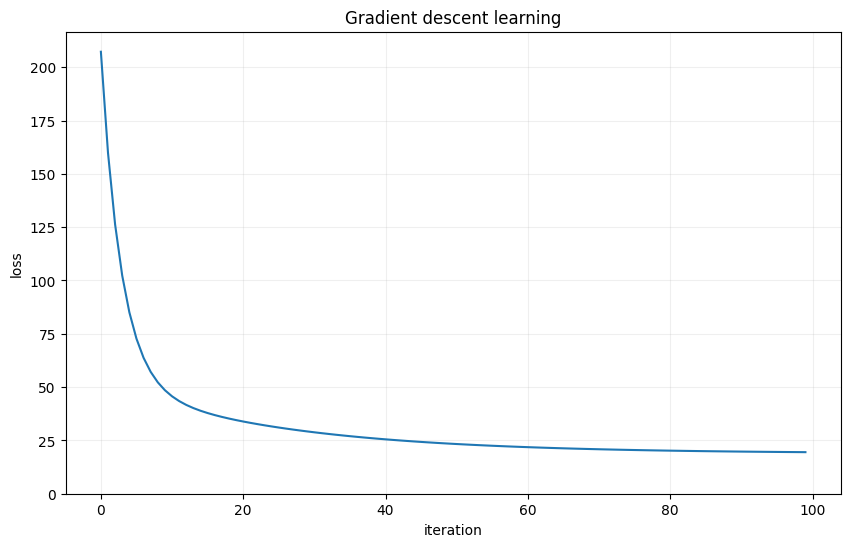

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(l)

plt.title('Gradient descent learning')
plt.ylabel('loss')
plt.xlabel('iteration')
plt.ylim(bottom=0)
plt.grid(alpha=0.2)

plt.show()

### 1.3 Стохастический градиентный спуск

Считать градиент по всей обучающей выборке на каждом шаге градиентного спуска слишком дорого. Стохастический градиентный спуск (SGD) -- это улучшение обычного градиентного спуска, которое позволяет решить эту проблему.

На каждой итерации градиентного спуска будем считать градиент функции потерь не по всей выборке, а лишь по подмножеству выборки фиксированного размера $k$ (такое подмножество называется **батч**). Существует несколько способов реализовать SGD:

1. На каждом шаге спуска выбирать случайный батч.
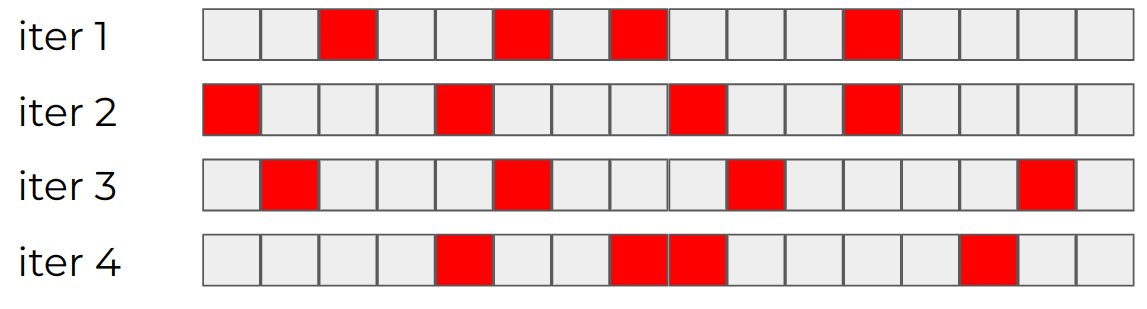
2. Разделить обучение на эпохи, на каждой эпохе перемешивать выборку и проходиться батчами по всем элементам выборки.
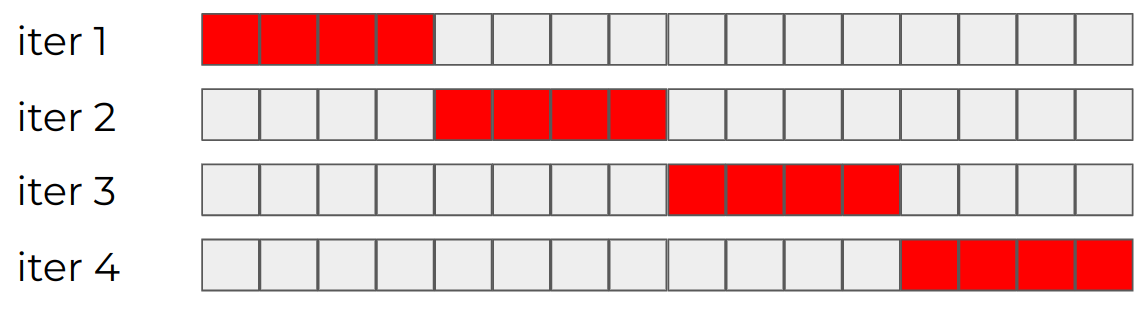



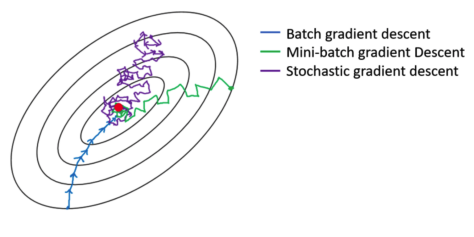

Второй способ вам необходимо будет использовать в домашнем задании. Для этого вам предстоит разобраться в генераторах в Python. Статья, которая вам в этом поможет: [тык](https://pythonru.com/uroki/30-generatory-dlja-nachinajushhih).

**Кратко** (благодарим Ольгу Липину, нашу слушательницу, которая написала этот комментарий к домашнему заданию):




> `yield` - это аналог `return`. Только `return` сразу выкидывает нас из функции, возвращая значение. А `yield` возвращает значение, и функция переходит в режим ожидания. И если мы вызовем её ещё раз, она продолжит работу с того же места, на котором остановилась.
>
> С помощью `yield` пишут генераторы. Конкретно здесь от нас хотят, чтоб мы написали генератор батчей. `yield` на каждом шаге возвращает `(batch_x, batch_y)`. И мы пишем цикл, который считает `batch_x`, `batch_y` и делает `yield batch_x, batch_y`. Таким образом, когда мы проходимся по объекту-генератору, функция на каждом шаге:
>
> 1. Возвращает нам батч.
> 2. Останавливается, запоминая предыдущее состояние.
> 3. На следующем шаге с текущего состояния, которое она помнит, возвращает новый батч

Если сейчас этот текст непонятен, ничего страшного. Вернитесь к нему, когда будете решать домашнее задание.


Мы будем пользоваться первым способом, потому что его проще реализовать. Добавим к нашему градиентному спуску сэмплирование батча, по которому будем считать градиент


In [ ]:
class MySGDLinearRegression(MyGradientLinearRegression):
    def __init__(self, n_sample=10, **kwargs):

        '''**kwargs` собирает все **именованные аргументы**, которые не были явно объявлены в функции. В вашем классе `MySGDLinearRegression`
        определён только один параметр `n_sample`. Если вы попытаетесь создать объект с дополнительным параметром, например:
        model = MySGDLinearRegression(n_sample=20, lr=0.001)
        то `lr=0.001` попадёт в `kwargs`, и потом будет передан в конструктор родителя через `super().__init__(**kwargs)`.
        В родительском классе `MyGradientLinearRegression` этот аргумент, возможно, нужен для инициализации. Если бы мы не использовали
        `**kwargs`, то вызов с `lr` вызвал бы ошибку, потому что конструктор дочернего класса не принимает такой параметр.

        Таким образом, `**kwargs` позволяет дочернему классу принимать любые параметры, которые могут понадобиться родителю,
        не перечисляя их явно. Это делает код более гибким и снижает дублирование.
        '''
        super().__init__(**kwargs) # передает именные параметры родительскому конструктору
        self.w = None
        self.n_sample = n_sample

    def _calc_gradient(self, X, y, y_pred):
        # Главное отличие в SGD -- это использование подвыборки для шага оптимизации
        inds = np.random.choice(np.arange(X.shape[0]), size=self.n_sample, replace=False)
#np.arange(X.shape[0]) создаёт массив индексов от 0 до l-1, где l = X.shape[0] — это количество объектов в обучающей выборке.
#np.random.choice(..., size=self.n_sample, replace=False) случайным образом выбирает self.n_sample уникальных индексов из этого диапазона.
#replace=False гарантирует, что один и тот же объект не попадёт в батч дважды.
        grad = 2 / self.n_sample * X[inds].T @ (y_pred[inds] - y[inds])

        return grad

#### Тестирование

Проведем аналогичный расчет на сгенерированном датасете

In [ ]:
regressor = MySGDLinearRegression()

l = regressor.fit(X_train[:, np.newaxis], y_train, max_iter=100).get_losses()

predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weights()

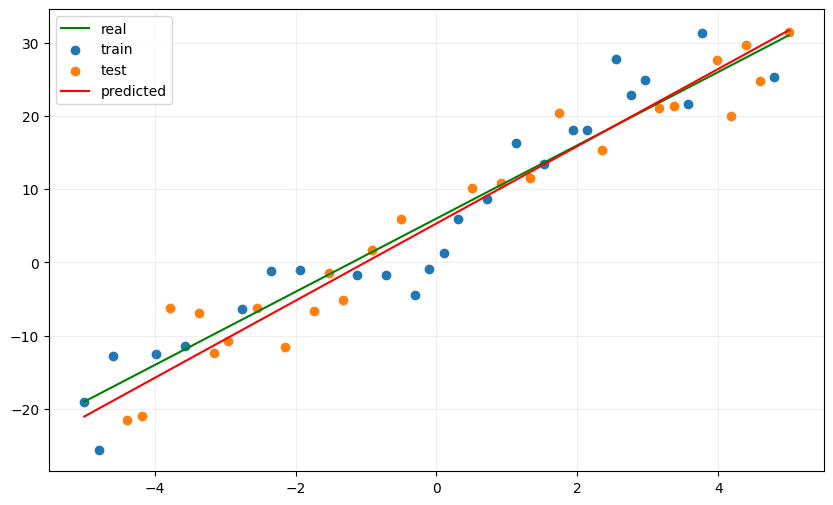

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

plt.grid(alpha=0.2)
plt.legend()
plt.show()

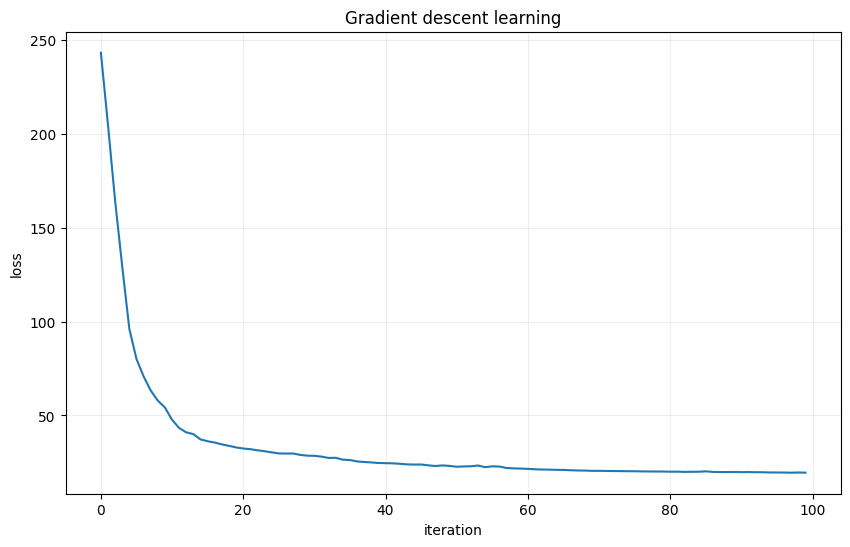

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(l)

plt.title('Gradient descent learning')
plt.ylabel('loss')
plt.xlabel('iteration')
plt.grid(alpha=0.2)
plt.show()

Протестируем, меняя количество элементов для расчета градиента

In [ ]:
n_samples = [1, 8, 16, 23] #батчи

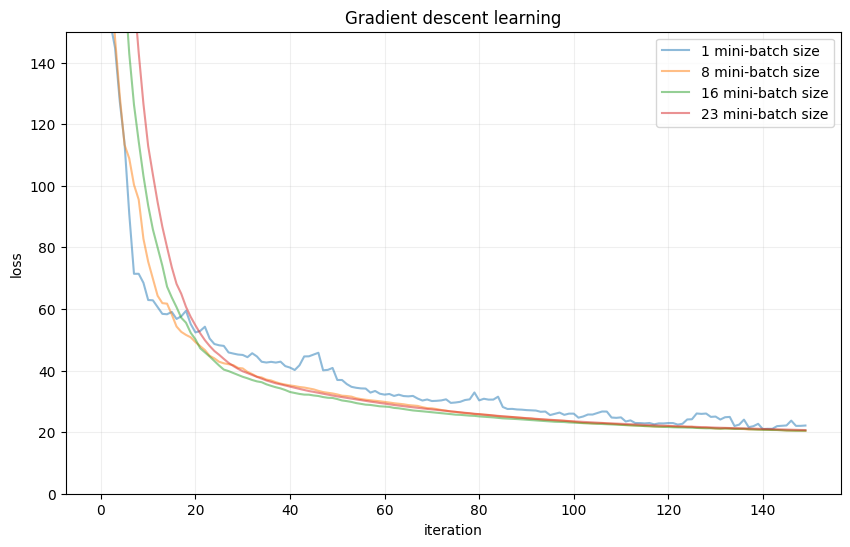

In [ ]:
plt.figure(figsize=(10, 6))

for ns in n_samples:
  #такие приколы как раз из-за kwards можно делать
    l = MySGDLinearRegression(n_sample=ns).fit(
        X_train[:, np.newaxis],
        y_train,
        lr=5e-3,
        max_iter=150,
    ).get_losses()
    plt.plot(l, alpha=0.5, label=f'{ns} mini-batch size')

plt.title('Gradient descent learning')
plt.ylabel('loss')
plt.xlabel('iteration')

plt.legend()
plt.ylim((0, 150))
plt.grid(alpha=0.2)
plt.show()

Как видно по графикам, размер подвыборки влияет на стабильность сходимости (чем меньше, тем больше и резче изменения весов).
При этом количество итераций для минимизации примерно одинаково.

SGD также обычно улучшают адаптивным уменьшением величины шага (подробнее в курсах про методы оптимизаций)
